## 01_Setup and Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [2]:
df = sns.load_dataset('titanic')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 02_Understand the Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
missing = df.isnull().sum()
print(missing[missing>0])

age            177
embarked         2
deck           688
embark_town      2
dtype: int64


## Clean the Data

Handle missing values

In [6]:
# age
df['age'].fillna(df['age'].median(),inplace = True)
# embarked
df['embarked'].fillna(df['embarked'].mode()[0],inplace = True)

# embard_town
df['embark_town'].fillna(df['embark_town'].mode()[0],inplace = True)

# deck has too many missing values(~ 77%) -- not worth keeping
# we will just drop them.
df.drop(columns=['deck'],inplace = True)

# checking null values again for confirmation
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


## Visualize Patterns

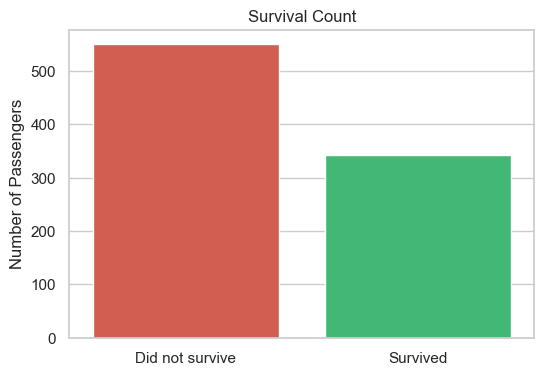

In [7]:
# --- Chart 1: Overall survival count ---
# (0 = did not survive, 1 = survived)

plt.figure(figsize=(6,4))
sns.countplot(data = df,x = 'survived', palette=['#e74c3c', '#2ecc71'])
plt.xticks([0, 1], ['Did not survive', 'Survived'])
plt.title('Survival Count')
plt.xlabel('')
plt.ylabel('Number of Passengers')
plt.show()


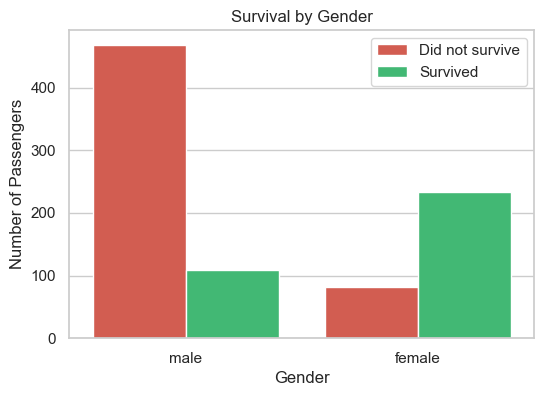

In [8]:
# --- Chart 2: Survival by gender ---
# Did men or women have a better chance?
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sex', hue='survived', palette=['#e74c3c', '#2ecc71'])
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(['Did not survive', 'Survived'])
plt.show()

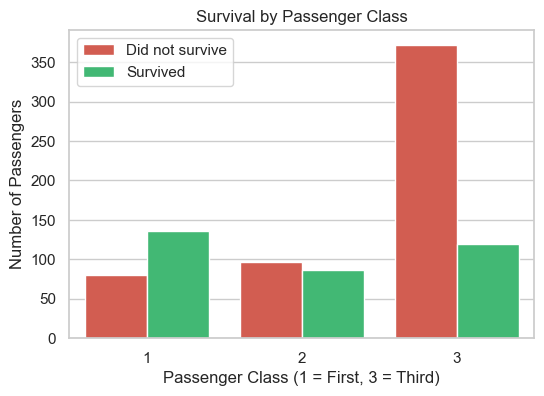

In [9]:
# --- Chart 3: Survival by passenger class ---
# pclass = 1 (First class), 2 (Second), 3 (Third/cheapest)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='pclass', hue='survived', palette=['#e74c3c', '#2ecc71'])
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class (1 = First, 3 = Third)')
plt.ylabel('Number of Passengers')
plt.legend(['Did not survive', 'Survived'])
plt.show()

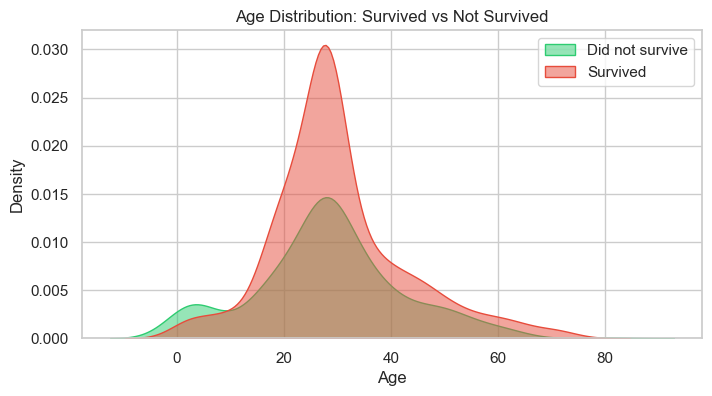

In [10]:
# --- Chart 4: Age distribution of survivors vs non-survivors ---
# A KDE (Kernel Density Estimate) plot shows the shape of the age distribution

plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='age', hue='survived', fill=True, 
            palette=['#e74c3c', '#2ecc71'], alpha=0.5)
plt.title('Age Distribution: Survived vs Not Survived')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(['Did not survive', 'Survived'])
plt.show()

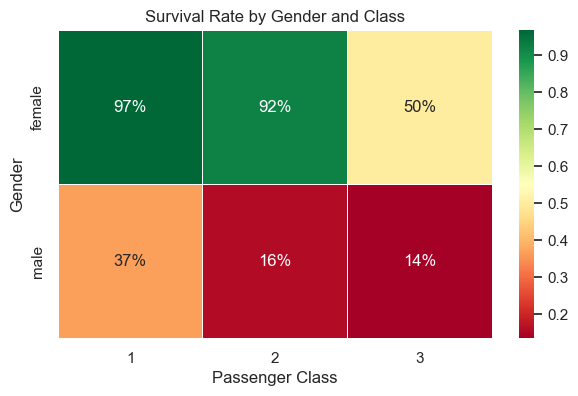

In [11]:
# --- Chart 5: Survival rate by gender AND class together ---
# survival rate per group
pivot = df.pivot_table(values = "survived", index = "sex", columns = "pclass", aggfunc = "mean")

plt.figure(figsize=(7,4))
sns.heatmap(pivot, annot = True, fmt = ".0%", cmap = "RdYlGn",
            linewidths=0.5, linecolor= "white")
plt.title('Survival Rate by Gender and Class')
plt.xlabel('Passenger Class')
plt.ylabel('Gender')
plt.show()


## Key Insights

1. Only ~38% of passengers survived overall.
2. Women survived at a much higher rate than men — "women and children first" was real.
3. First class passengers had a far better survival rate than third class.
4. Children (age < 10) had a slightly better survival rate.
5. The worst outcome: male, third-class passengers.

In [ ]:
# Survival rate as percentage
survival_by_gender = df.groupby('sex')['survived'].mean() * 100
print(survival_by_gender.round(1))

sex
female    74.2
male      18.9
Name: survived, dtype: float64


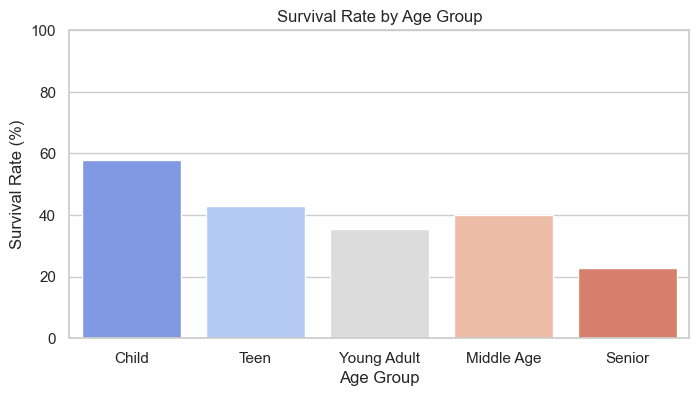

In [ ]:
# Survival rate by age
df["age_group"] = pd.cut(df['age'],
                         bins = [0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teen', 'Young Adult', 'Middle Age', 'Senior'])
plt.figure(figsize=(8, 4))
survival_by_age = df.groupby('age_group')['survived'].mean() * 100

sns.barplot(x=survival_by_age.index, y=survival_by_age.values, palette='coolwarm')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate (%)')
plt.ylim(0, 100)
plt.show()


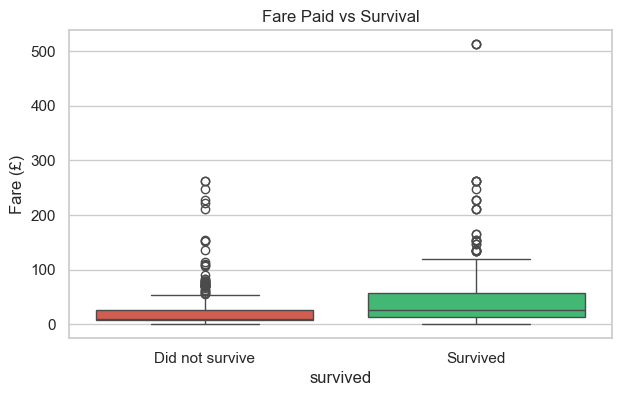

In [ ]:
#Fare vs survival
# Did paying more = better survival chance?
# A boxplot shows the spread of fare prices for each group

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='survived', y='fare', 
            palette=['#e74c3c', '#2ecc71'])
plt.xticks([0, 1], ['Did not survive', 'Survived'])
plt.title('Fare Paid vs Survival')
plt.ylabel('Fare (£)')
plt.show()

## Summary & Key Insights

### Dataset Overview
- Total passengers: 891
- Survival rate: ~38% (only 1 in 3 survived)

### What the data revealed

1. **Gender was the strongest factor** — 74.2% of women survived vs only 18.9% of men. 
   Women were 4x more likely to survive. "Women and children first" was real.

2. **Passenger class mattered** — First class passengers had significantly higher 
   survival rates than third class. Better cabin location = closer to lifeboats.

3. **Children had the best survival odds** — Despite young adults (age ~30) 
   appearing dominant in the KDE plot, that was due to volume. Children as a 
   group had the highest actual survival rate.

4. **Money = survival** — Survivors paid noticeably higher fares on average. 
   This connects directly to class — expensive ticket, better position on the ship.

5. **The worst outcome** — Male, third-class passengers had the lowest 
   survival rate by far.

### Conclusion
Survival on the Titanic was not random. Gender, class, and age together 
explain most of who lived and who didn't. This shows the power of EDA — 
before building any predictive model, understanding your data first 
leads to better questions and better decisions.